In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Data selection

In [2]:
X = pd.read_csv('..\\data\\train_scaled_X_20e3.csv')
y = pd.read_csv('..\\data\\train_y_20e3.csv')

In [3]:
X.shape, y.shape

((20000, 87), (20000, 1))

In [29]:
# X_train, X_test = train_test_split(X_benign, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# X_train.reset_index(inplace=True, drop=True)
# X_test.reset_index(inplace=True, drop=True)
# y_train.reset_index(inplace=True, drop=True)
# y_test.reset_index(inplace=True, drop=True)

In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16000, 87), (4000, 87), (16000, 1), (4000, 1))

In [31]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
5894,-1.474846,1.478107,-0.435883,-0.146731,-0.013617,-0.004096,-0.003787,-0.005694,1.630553,-0.360506,...,-0.258904,-0.250723,0.716066,-0.790015,-0.396723,-0.598894,-1.640728,1.489527,1.574288,-0.474998
3728,0.699316,-0.628660,2.175036,-0.326895,-0.014763,-0.012612,-0.019347,-0.005820,-0.656738,1.410399,...,-0.258904,-0.250723,0.716066,-0.790015,-0.460790,-0.168474,0.613090,-0.690405,-1.243080,-0.755710
8958,0.603647,-0.627486,-0.435883,-0.051692,-0.013617,-0.004096,-0.013824,-0.004407,0.212433,-0.360506,...,0.293693,0.319202,-1.388270,1.377401,1.877670,1.427667,0.613090,-0.690405,-0.235834,-0.397023
7671,0.569718,-0.627486,-0.435883,-0.291302,-0.014190,-0.004096,-0.020246,-0.004423,-0.694859,-0.360506,...,-0.258904,-0.250723,-1.388270,1.342814,1.701485,2.342310,0.613090,-0.690405,-0.235834,-0.397023
5999,0.896176,-0.628660,2.175036,-0.332537,-0.015337,-0.016871,-0.019742,-0.006194,-0.623699,2.068164,...,-0.258904,-0.250723,0.716066,-0.790015,-0.476807,1.140721,0.613090,-0.690405,-1.243080,-0.755710


In [22]:
y_test['Label'].value_counts()

Label
1    2070
0    1930
Name: count, dtype: int64

In [23]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,-1.474846,1.478107,-0.435883,-0.146731,-0.013617,-0.004096,-0.003787,-0.005694,1.630553,-0.360506,...,-0.258904,-0.250723,0.716066,-0.790015,-0.396723,-0.598894,-1.640728,1.489527,1.574288,-0.474998
1,0.699316,-0.628660,2.175036,-0.326895,-0.014763,-0.012612,-0.019347,-0.005820,-0.656738,1.410399,...,-0.258904,-0.250723,0.716066,-0.790015,-0.460790,-0.168474,0.613090,-0.690405,-1.243080,-0.755710
2,0.603647,-0.627486,-0.435883,-0.051692,-0.013617,-0.004096,-0.013824,-0.004407,0.212433,-0.360506,...,0.293693,0.319202,-1.388270,1.377401,1.877670,1.427667,0.613090,-0.690405,-0.235834,-0.397023
3,0.569718,-0.627486,-0.435883,-0.291302,-0.014190,-0.004096,-0.020246,-0.004423,-0.694859,-0.360506,...,-0.258904,-0.250723,-1.388270,1.342814,1.701485,2.342310,0.613090,-0.690405,-0.235834,-0.397023
4,0.896176,-0.628660,2.175036,-0.332537,-0.015337,-0.016871,-0.019742,-0.006194,-0.623699,2.068164,...,-0.258904,-0.250723,0.716066,-0.790015,-0.476807,1.140721,0.613090,-0.690405,-1.243080,-0.755710


In [24]:
y_train.head()

,Label
0,0
1,1
2,1
3,1
4,0


### Logistic Regression

In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train['Label'])

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
y_pred = model.predict(X_test)

#### Evaluation

In [34]:
print("Accuracy:", accuracy_score(y_test['Label'], y_pred))
print("\nClassification Report:\n", classification_report(y_test['Label'], y_pred))

Accuracy: 0.5155

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.43      0.46      1930
           1       0.53      0.59      0.56      2070

    accuracy                           0.52      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.52      0.51      4000



#### Confusion Matrix

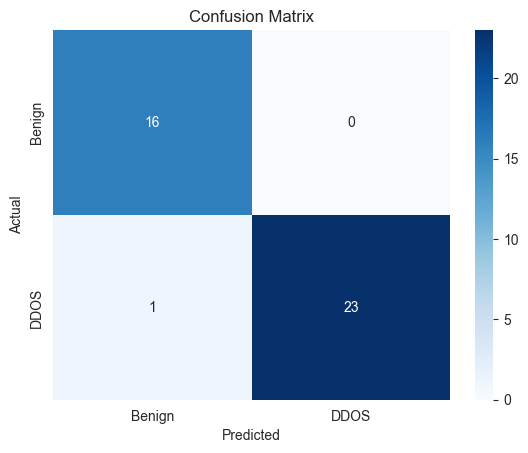

In [16]:
conf_matrix = confusion_matrix(y_test['Label'], y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### ROC Curve

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score


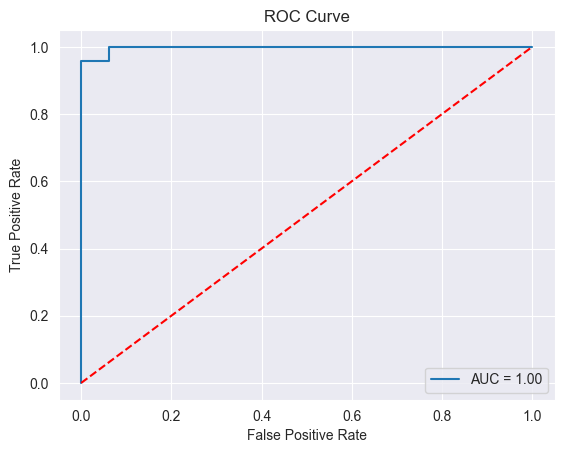

In [19]:
y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test['Label'], y_pred_proba)
auc = roc_auc_score(y_test['Label'], y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#### Feature Importance

Feature: 0, Score: -0.18361
Feature: 1, Score: -0.34521
Feature: 2, Score: -0.35467
Feature: 3, Score: -0.04391
Feature: 4, Score: -0.18706
Feature: 5, Score: -0.06922
Feature: 6, Score: -0.15513
Feature: 7, Score: -0.23608
Feature: 8, Score: 0.23461
Feature: 9, Score: -0.34330
Feature: 10, Score: 0.01736
Feature: 11, Score: 0.29647
Feature: 12, Score: -0.19080
Feature: 13, Score: -0.29799
Feature: 14, Score: -0.10672
Feature: 15, Score: 0.00785
Feature: 16, Score: 0.12385
Feature: 17, Score: -0.08562
Feature: 18, Score: 0.14664
Feature: 19, Score: 0.17843
Feature: 20, Score: 0.07381
Feature: 21, Score: 0.10837
Feature: 22, Score: -0.14365
Feature: 23, Score: 0.11737
Feature: 24, Score: -0.21353
Feature: 25, Score: -0.10883
Feature: 26, Score: 0.10871
Feature: 27, Score: -0.04287
Feature: 28, Score: 0.40834
Feature: 29, Score: 0.19699
Feature: 30, Score: 0.02661
Feature: 31, Score: -0.15535
Feature: 32, Score: -0.62227
Feature: 33, Score: 0.00000
Feature: 34, Score: 0.00000
Feature: 35

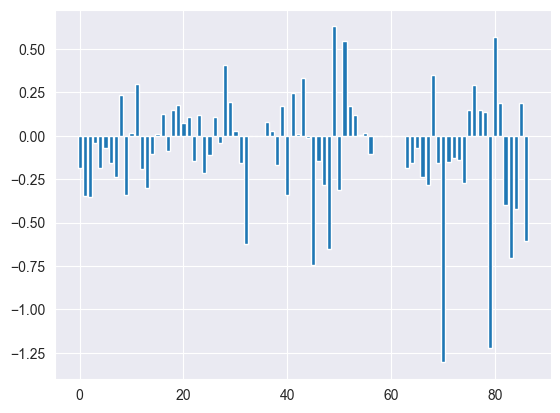

In [20]:
importance = model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.show()


### Save the model

In [21]:
import joblib
joblib.dump(model, '..\\models\\logistic_regression.pkl')

['..\\models\\logistic_regression.pkl']

In [ ]:
y = round(w1 * f1 + w2 * f2 + w3 * f3 + ...)    # if y = 1, then DDOS else Benign